In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("totul merge")

totul merge


In [50]:
%pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [51]:
df = pd.read_excel("online+retail+ii/online_retail_II.xlsx")

In [52]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [53]:
df.shape

(525461, 8)

In [54]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845018,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


## Phase 1 - Orientation

In [55]:
df[['Invoice','StockCode','Customer ID','Country']].nunique()

Invoice        28816
StockCode       4632
Customer ID     4383
Country           40
dtype: int64

**Phase 1 - Orientation.** Unique counts per key column:

- **Invoice:** 28,816 unique orders
- **StockCode:** 4,632 unique products
- **Customer ID:** 4,383 unique customers
- **Country:** 40 unique countries

## Phase 2 - Univariate analysis

**2. Which countries do most orders come from?** (`value_counts()` on `Country`)

In [56]:
# Number of rows (line items) per country
number_of_orders=df['Country'].value_counts()

**Most frequent products (top 10 by line-item count).**

In [57]:
best_sellers = df['Description'].value_counts(10)
best_sellers

Description
WHITE HANGING HEART T-LIGHT HOLDER    0.006792
REGENCY CAKESTAND 3 TIER              0.004233
STRAWBERRY CERAMIC TRINKET BOX        0.003527
PACK OF 72 RETRO SPOT CAKE CASES      0.002806
ASSORTED COLOUR BIRD ORNAMENT         0.002788
                                        ...   
GLASS BELL JAR LARGE                  0.000002
SILICON CUBE 25W, BLUE                0.000002
BAKING MOULD EASTER EGG MILK CHOC     0.000002
*Boombox Ipod Classic                 0.000002
faulty                                0.000002
Name: proportion, Length: 4681, dtype: float64

In [58]:
df["Quantity"].describe()



count    525461.000000
mean         10.337667
std         107.424110
min       -9600.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       19152.000000
Name: Quantity, dtype: float64

`Quantity` has `min = -9600` (not a realistic sale) and a very large `max`. These extremes distort the histogram, so the raw plot does not show the true distribution.

(array([1.00000e+01, 2.30000e+01, 7.30000e+01, 5.25223e+05, 8.70000e+01,
        3.10000e+01, 9.00000e+00, 4.00000e+00, 0.00000e+00, 1.00000e+00]),
 array([-9600. , -6724.8, -3849.6,  -974.4,  1900.8,  4776. ,  7651.2,
        10526.4, 13401.6, 16276.8, 19152. ]),
 <BarContainer object of 10 artists>)

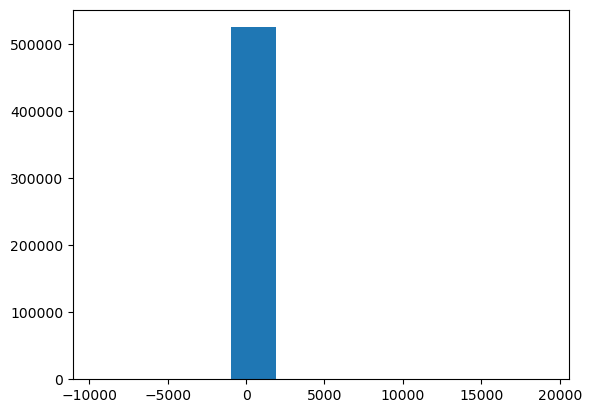

In [59]:
plt.hist(df["Quantity"])

`Price` has a very low (negative) min and a very high max. A boolean mask (a sensible price range) is needed to see the real distribution in the histogram.

In [60]:
df["Price"].describe()

count    525461.000000
mean          4.688834
std         146.126914
min      -53594.360000
25%           1.250000
50%           2.100000
75%           4.210000
max       25111.090000
Name: Price, dtype: float64

**Time span of the data:** from `2009-12-01 07:45:00` to `2010-12-09 20:01:00` (about one year).

In [61]:
df["InvoiceDate"].min()

Timestamp('2009-12-01 07:45:00')

In [62]:
df["InvoiceDate"].max()

Timestamp('2010-12-09 20:01:00')

## Phase 3 - Data quality

**7. Missing values per column** (`df.isnull().sum()`):

- `Description`: 2,928 NaN
- `Customer ID`: 107,927 NaN

Many transactions have no customer attached - relevant for any customer-level analysis (exercise 10).

In [63]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

**8. Duplicate rows.** Why are there duplicate rows? (`df.duplicated().sum()` ~ 6,865 fully identical rows.)

In [64]:
df.duplicated(keep=False)

0         False
1         False
2         False
3         False
4         False
          ...  
525456    False
525457    False
525458    False
525459    False
525460    False
Length: 525461, dtype: bool

In [65]:
df[df.duplicated(keep=False)]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
367,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
...,...,...,...,...,...,...,...,...
525170,538155,21907,I'M ON HOLIDAY METAL SIGN,1,2010-12-09 16:52:00,2.10,16907.0,United Kingdom
525292,538166,21915,RED HARMONICA IN BOX,5,2010-12-09 18:09:00,1.25,17965.0,United Kingdom
525293,538166,21915,RED HARMONICA IN BOX,5,2010-12-09 18:09:00,1.25,17965.0,United Kingdom
525330,538168,22739,RIBBON REEL CHRISTMAS SOCK BAUBLE,5,2010-12-09 19:23:00,1.65,14702.0,United Kingdom


You cannot sort directly by `Invoice`: the column mixes numeric-only orders (`int`) and codes containing letters (`str`), which raises a `TypeError`. Invoices starting with **`C`** are orders returned / cancelled by the customer.

In [66]:
df[df.duplicated(keep=False)].sort_values("Invoice")


TypeError: '<' not supported between instances of 'str' and 'int'

**9. Quantity checks.** `Quantity` has no missing values. Next we inspect the negative quantities.

In [ ]:
df["Quantity"].isnull().sum()

In [ ]:
df["Quantity"].isnull().sum()
df[df["Quantity"] < 0].head(20)

In [ ]:
df[(df["Quantity"] < 0) & (~df["Invoice"].astype(str).str.startswith("C"))].head()

In [ ]:
neg = df[(df["Quantity"] < 0) & (~df["Invoice"].astype(str).str.startswith("C"))]

Negative quantities do not come only from cancellations (`C...` invoices) - some also come from **internal adjustment notes** (e.g. damages, lost stock).

In [ ]:
neg["Description"].value_counts()

## Phase 4 - Relationships & insights

**11. New column `Revenue` = `Quantity` * `Price`.**

In [68]:
# Create Revenue column = Quantity * Price
df["Revenue"] = df["Quantity"] * df["Price"]
df["Revenue"]

0          83.40
1          81.00
2          81.00
3         100.80
4          30.00
           ...  
525456      5.90
525457      3.75
525458      3.75
525459      7.50
525460      3.90
Name: Revenue, Length: 525461, dtype: float64

Note: part of the top revenue comes from **shipping / postage** (e.g. `POSTAGE`, `Manual`), not from actual goods.

In [69]:
top_revenue = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)

**13. Revenue by country.** Most revenue comes from the **United Kingdom**; every other country is comparatively very small.

In [ ]:
df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)

In [ ]:
df["InvoiceDate"].dtype


In [ ]:
df['InvoiceDate'].dt.to_period("M")

**14. Revenue over time (monthly).** Revenue rises toward the **autumn/winter months** - a seasonal peak before Christmas.

Text(0, 0.5, 'Venit')

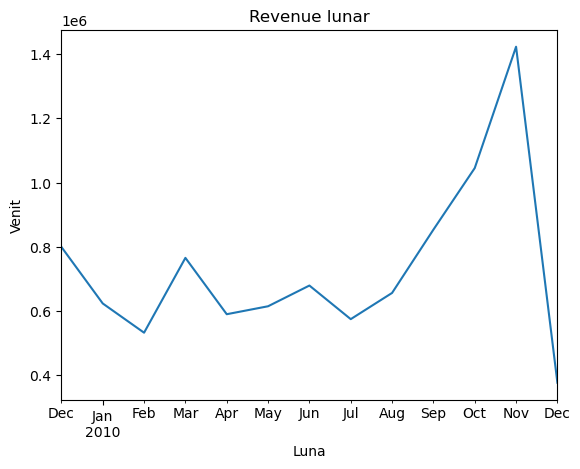

In [80]:
monthly_revenue = df.groupby(df["InvoiceDate"].dt.to_period("M"))["Revenue"].sum()
monthly_revenue.plot()
plt.title("Monthly revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")

## Extra - outliers, multi-library charts & business questions

**15. Outlier hunting - `Quantity` histogram, filtered.** Restricting to `0 < Quantity < 100` to see the bulk of the distribution without the extreme outliers.

In [ ]:
df[(df["Quantity"]>0) & (df["Quantity"]<100)].describe()

,Quantity,InvoiceDate,Price,Customer ID
count,506078.000000,506078,506078.000000,400982.000000
mean,7.589498,2010-06-29 01:44:42.630306,4.010858,15369.743283
min,1.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 15:36:00,1.250000,13999.000000
50%,3.000000,2010-07-07 11:17:00,2.100000,15328.000000
75%,10.000000,2010-10-17 11:24:00,4.210000,16814.000000
max,99.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,11.384632,NaN,128.841387,1679.024359


In [ ]:
quantity_normal=df[(df["Quantity"]>0) & (df["Quantity"]<100)]

(array([3.84861e+05, 7.25320e+04, 2.96960e+04, 6.29500e+03, 6.30800e+03,
        1.15200e+03, 1.15500e+03, 2.01800e+03, 2.91000e+02, 1.77000e+03]),
 array([ 1. , 10.8, 20.6, 30.4, 40.2, 50. , 59.8, 69.6, 79.4, 89.2, 99. ]),
 <BarContainer object of 10 artists>)

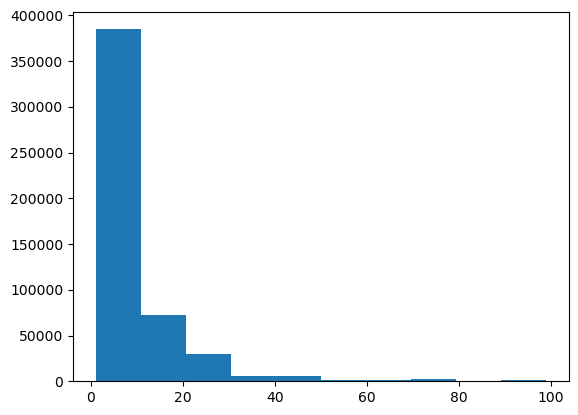

In [ ]:
plt.hist(quantity_normal["Quantity"])

**Top products by revenue (seaborn barplot).** Note: `sns.barplot` needs a DataFrame, so we `reset_index()` first.

<Axes: xlabel='Revenue', ylabel='Description'>

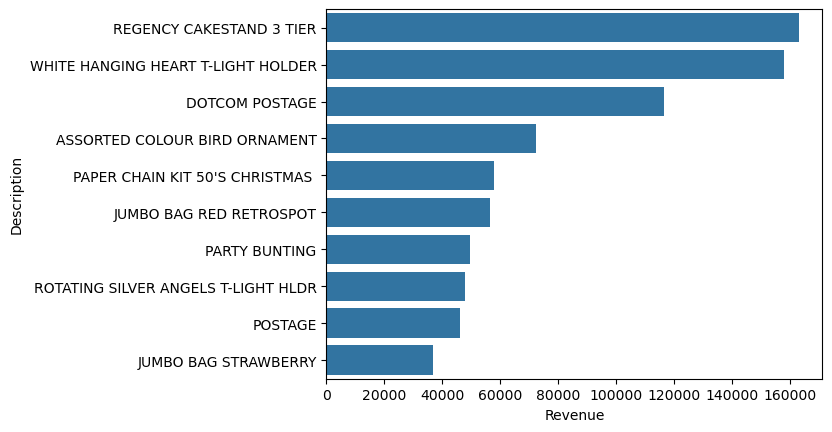

In [71]:
top_revenue_df=top_revenue.reset_index()
sns.barplot(data=top_revenue_df,x="Revenue",y="Description")

In [82]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


**Top 10 countries by revenue, excluding the UK** (so the smaller markets become visible).

<Axes: xlabel='Revenue', ylabel='Country'>

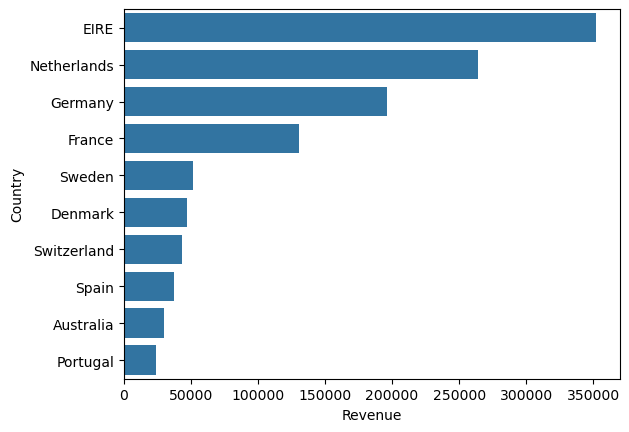

In [86]:
best_rev_by_country = df[df["Country"]!="United Kingdom"].groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)
best_rev_by_country_df=best_rev_by_country.reset_index()
sns.barplot(data=best_rev_by_country_df,x="Revenue",y="Country")

**16. Turning conclusions into charts (matplotlib + seaborn).** Extra exploratory plots: price histogram, quantity boxplots, and a price-vs-quantity scatter.

Text(0, 0.5, 'Numarul de obiecte vandute')

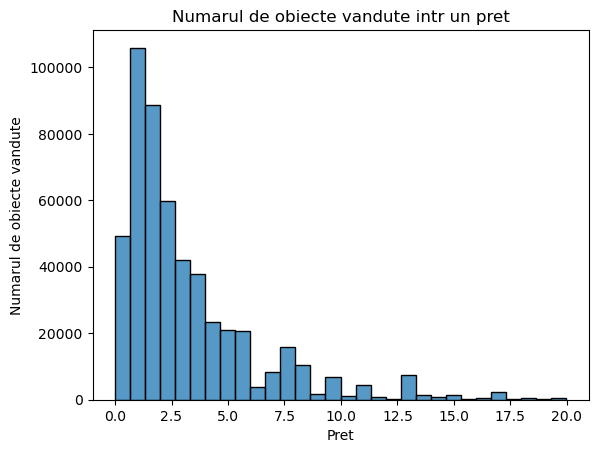

In [96]:
price_filtered = df[(df["Price"]>0)& (df["Price"]<20)]
price_filtered_df=price_filtered.reset_index()
sns.histplot(data=price_filtered_df,x="Price",bins=30)
plt.title("Number of items sold per price")
plt.xlabel("Price")
plt.ylabel("Number of items sold")

<Axes: ylabel='Quantity'>

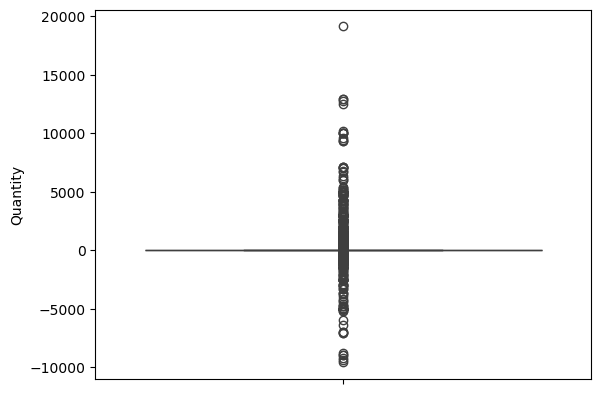

In [101]:

sns.boxplot(data=df["Quantity"])

<Axes: ylabel='Quantity'>

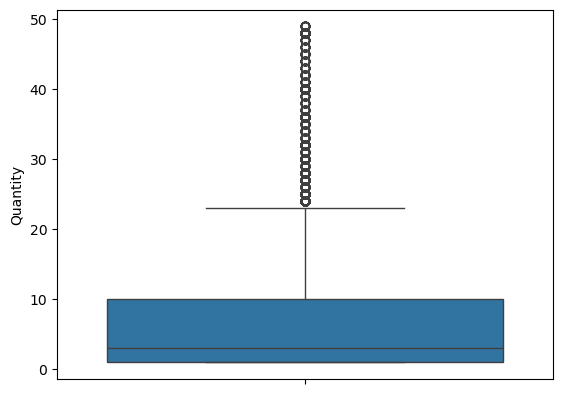

In [108]:
quantity_filtered=df[(df["Quantity"]>0) & (df["Quantity"]<50)]
sns.boxplot(data=quantity_filtered["Quantity"])

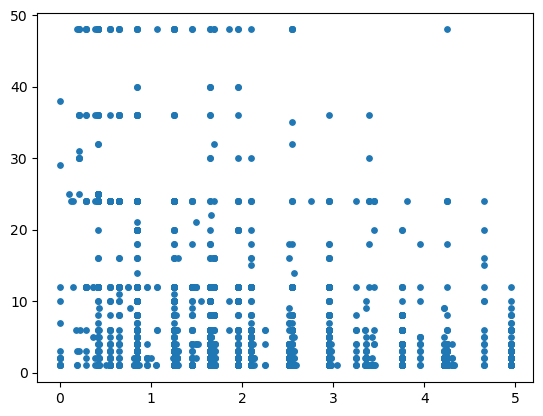

In [125]:

price_quantity=df[(df["Quantity"]>0) & (df["Quantity"]<50)&(df["Price"]>=0)&(df["Price"]<=5)].sample(3000)
plt.scatter(x=price_quantity["Price"],y=price_quantity["Quantity"],alpha=1,s=15)

**Correlation heatmap (seaborn).** Compute the correlation matrix on the numeric columns only (`corr(numeric_only=True)`, since some columns are text), then plot it with `sns.heatmap`. The insight here is limited (few numeric columns), but the technique matters for Project 1.

<Axes: >

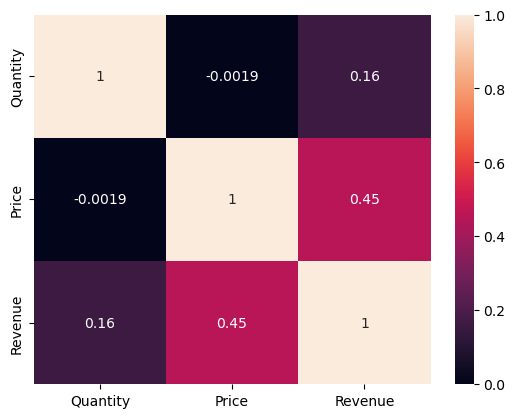

In [128]:
cor=df.drop(columns="Customer ID").corr(numeric_only=True)
sns.heatmap(data=cor,annot=True)

**18. Business questions.**

**Top customers by total revenue.**

<Axes: xlabel='Customer ID', ylabel='Revenue'>

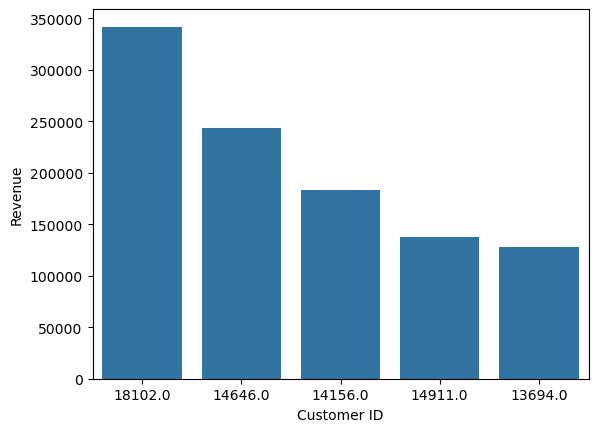

In [139]:
# Top customers by total revenue
customer = df[df["Customer ID"]>0].groupby("Customer ID")["Revenue"].sum().sort_values(ascending=False).head()
customer_df=customer.reset_index()
customer_df["Customer ID"]=customer_df["Customer ID"].astype(str)
sns.barplot(data=customer_df,y="Revenue",x="Customer ID")

**Cancellation rate** (total and per month). Cancellations are invoices whose code starts with **`C`**.

Text(0, 0.5, 'Numarul de returnari')

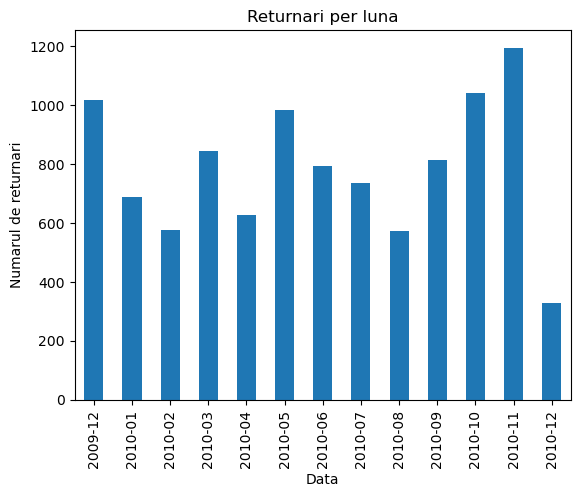

In [149]:
# Cancellation rate per month (invoices starting with "C" are cancellations)
returns=df[df["Invoice"].astype(str).str.startswith("C")]
total_per_month =df.groupby(df["InvoiceDate"].dt.to_period("M"))["Quantity"].count()
returns_per_month=returns.groupby(returns["InvoiceDate"].dt.to_period("M"))["Quantity"].count()
rate = returns_per_month / total_per_month
returns_per_month.plot(kind="bar")
plt.title("Returns per month")
plt.xlabel("Date")
plt.ylabel("Number of returns")


Text(0, 0.5, 'Valoarea ratei')

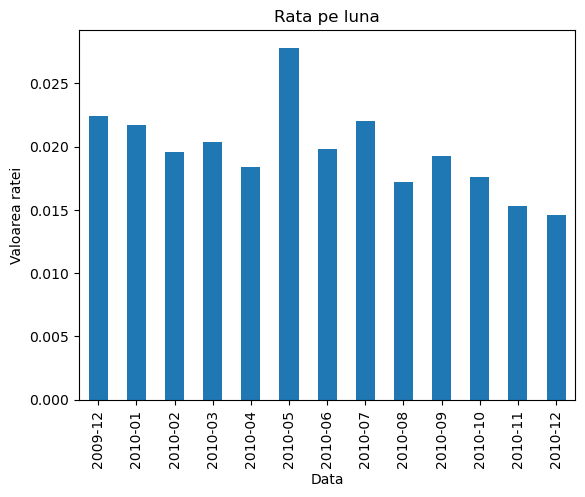

In [151]:
rate.plot(kind="bar")
plt.title("Cancellation rate per month")
plt.xlabel("Date")
plt.ylabel("Rate value")

**Wholesale vs retail customers.** Distribution of the per-invoice total value - small invoices are retail, large invoices are wholesale.

<Axes: ylabel='Frequency'>

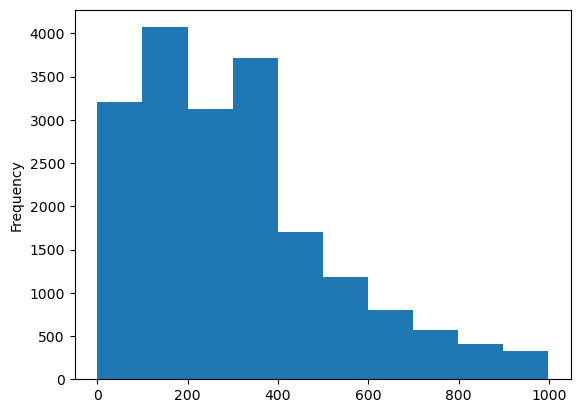

In [168]:
# Per-invoice totals distribution (wholesale vs retail), zoomed to 0-1000
invoice_totals=df[~df["Invoice"].astype(str).str.startswith("C")].groupby("Invoice")["Revenue"].sum()
invoice_totals[(invoice_totals > 0) & (invoice_totals < 1000)].plot(kind="hist")


**Top 10 products by total quantity sold.**

In [169]:
df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)

Description
WHITE HANGING HEART T-LIGHT HOLDER    57733
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54698
BROCADE RING PURSE                    47647
PACK OF 72 RETRO SPOT CAKE CASES      46106
ASSORTED COLOUR BIRD ORNAMENT         44925
60 TEATIME FAIRY CAKE CASES           36326
PACK OF 60 PINK PAISLEY CAKE CASES    31822
JUMBO BAG RED RETROSPOT               30727
SMALL POPCORN HOLDER                  29500
STRAWBERRY CERAMIC TRINKET BOX        26563
Name: Quantity, dtype: int64